5.3 OPENAI API로 다중모달 벡터 인덱싱하기
- 다중모달 검색 시스템을 효과적으로 구축하려면 텍스트와 이미지 데이터를 벡터화하고 인덱싱하는 과정은 필수적이다
- OpenAIMultiModal : 텍스트/이미지 데이터 동시 처리 가능
   + GPT-4o-mini 활용

In [3]:
from llama_index.multi_modal_llms.openai import OpenAIMultiModal
from llama_index.core import SimpleDirectoryReader
from llama_index.core.schema import ImageDocument
import os

OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

#이미지 데이터 로딩
image_documents = SimpleDirectoryReader("wiki_downloads").load_data()

documents = []
for doc in image_documents:
    if isinstance(doc, ImageDocument):
        documents.append(doc)

#OpenAI 다중 모달 모델 설정
openai_mm_llm = OpenAIMultiModal(model="gpt-4o-mini", api_key=OPENAI_API_KEY, max_new_tokens = 1500)

#이미지 데이터를 텍스트로 변환
response_1 = openai_mm_llm.complete(
    prompt = "이미지를 텍스트로 설명해주세요.",
    image_documents = documents[:2],
)

print(response_1)

첫 번째 이미지는 빈센트 반 고흐의 "아를의 침실"이라는 작품으로, 노란색 침대와 나무 바닥이 특징입니다. 방 안에는 창문과 테이블, 의자들이 있으며, 벽에는 여러 개의 그림이 걸려 있습니다. 전체적으로 따뜻한 색조와 단순한 형태가 돋보입니다.

두 번째 이미지는 폴 세잔의 "카드 놀이하는 남자들"이라는 작품입니다. 두 남성이 테이블에 앉아 카드 게임을 하고 있으며, 그들의 표정은 집중하고 있습니다. 테이블은 주황색으로 보이며, 배경은 어두운 색조로 처리되어 있습니다. 세잔의 독특한 붓 터치와 색상 사용이 특징적입니다.


5.4 쿼드런트를 활용한 다중모달 RAG 구축하기
- 쿼드런트(Qdrant) : 벡터 검색을 위한 강력한 오픈 소스 데이터베이스, 다중모달 검색 시스템 구축시 적합
  이미지/텍스트 데이터를 동시에 저장/검색 기능 제공
  로컬/클라우드 환경 제공
- 쿼드런트 벡터 스토어 요소
  . collection:데이터가 저장되는 컬렉션을 포함하는 폴더
  . image_colleciton:이미지 데이터를 위한 벡터 컬렉션
  . storage.sqlite:쿼드런트가 내부적으로 사용하는 SQLite 데이터 베이스 파일, 벡터/메타데이터 저장소 역할
  . text_collection:텍스트 데이터를 위한 벡터 컬렉션
  . meta.json:쿼드런트 데이터베이스의 메타데이터를 저장하는 Json파일, 컬렉션 정보 및 설정값을 포함
- QdrantClient : 벡터 스토어
- QdrantVectorStore : 벡터 저장소
- MultiModalVectorStoreIndex : 텍스트/이미지 임베딩하여 저장하는 인덱스
  텍스트 : llama-index 또는 사용자가 지정
  이미지 : CLIP 멀티모달 임베딩 모델 필요

In [4]:
!pip install qdrant-client
!pip install llama-index-vector-stores-qdrant
import qdrant_client
from llama_index.vector_stores.qdrant import QdrantVectorStore

#로컬 쿼드런트 벡터 스토어 생성
client = qdrant_client.QdrantClient(path="qdrant_mm_db")

In [6]:
#텍스트/이미지 벡터 저장소 생성
text_store = QdrantVectorStore(client=client, collection_name="text_cllection")
image_store = QdrantVectorStore(client=client, collection_name="image_collection")

In [7]:
!pip install git+https://github.com/openai/CLIP.git
!pip install llama-index-embeddings-clip

  Cloning https://github.com/openai/CLIP.git to /private/var/folders/tx/rrdzvfm55r182npmm9s21r_h0000gn/T/pip-req-build-hili8kwy
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/tx/rrdzvfm55r182npmm9s21r_h0000gn/T/pip-req-build-hili8kwy
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 7.5 MB/s  0:00:00 eta 0:00:01
  DEPRECATION: Building 'clip' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'clip'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for clip: f

In [8]:
from llama_index.core import SimpleDirectoryReader, StorageContext
from llama_index.core.indices import MultiModalVectorStoreIndex

#스토리지 컨텍스트 설정
storage_context = StorageContext.from_defaults(vector_store=text_store, image_store=image_store)

#문서 데이터 로딩
documents = SimpleDirectoryReader("wiki_downloads").load_data()

#멀티모달 벡터 인덱스 생성
index = MultiModalVectorStoreIndex.from_documents(documents, storage_context=storage_context)

100%|███████████████████████████████████████| 338M/338M [00:38<00:00, 9.26MiB/s]
/opt/anaconda3/lib/python3.12/site-packages/llama_index/vector_stores/qdrant/base.py:637: UserWarning: Payload indexes have no effect in the local Qdrant. Please use server Qdrant if you need payload indexes.
  self._client.create_payload_index(


In [12]:
#텍스트 검색을 위한 설정
MAX_TOKENS = 100
#검색 엔진 생성
retriever_engine = index.as_retriever(image_similarity_top_k=3)

#검색할 질문 입력
question = "Introduce representative works of Monet"
retrieval_results = retriever_engine.retrieve(question)
print(retrieval_results)

[NodeWithScore(node=TextNode(id_='edab3dce-642d-4d80-9cec-442f3326de78', embedding=None, metadata={'file_path': '/Users/baghyeonmi/Documents/LLM_RAG/llamaindex/ch05/wiki_downloads/Water_Lilies_(Monet_series).txt', 'file_name': 'Water_Lilies_(Monet_series).txt', 'file_type': 'text/plain', 'file_size': 4426, 'creation_date': '2025-08-31', 'last_modified_date': '2025-08-31'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='824bdfd1-da94-4724-9199-6792b128575a', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'file_path': '/Users/baghyeonmi/Documents/LLM_RAG/llamaindex/ch05/wiki_downloads/Water_Lilies_(Monet_series).txt', 'file_name': 'Water_Lilies_(Monet_series).txt', 'file_type': 'text/plain', 'file_size': 44

In [13]:
#이미지 시각화, 최대 9장까지 배치
!pip install matplotlib
import matplotlib.pyplot as plt
from PIL import Image

def plot_images(image_paths):
    images_shown = 0
    plt.figure(figsize=(16,9))
    for img_path in image_paths:
        if os.path.isfile(img_path):
            image = Image.open(img_path)

            plt.subplot(2,3, images_shown+1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 9:
                break

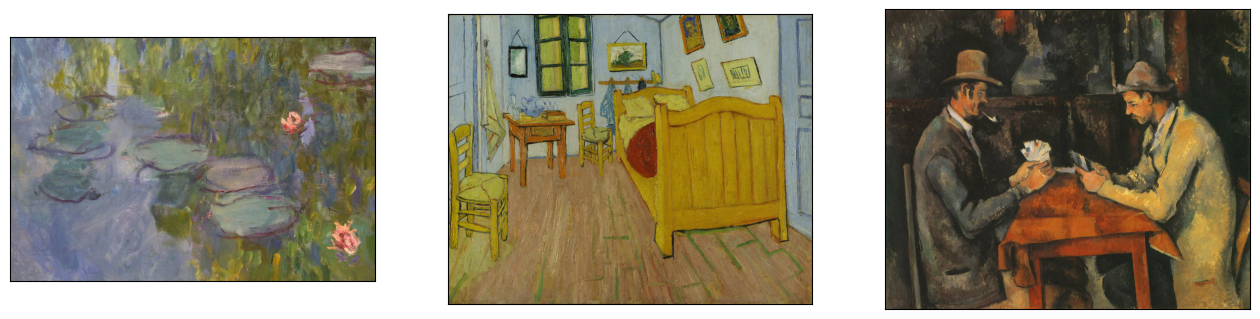

In [14]:
from llama_index.core.schema import ImageNode

retrieval_image = []
for res_node in retrieval_results:
    if isinstance(res_node.node, ImageNode):
        retrieval_image.append(res_node.node.metadata["file_path"])

#검색된 이미지 출력
plot_images(retrieval_image)

5.5 질의응답 기반 RAG 시스템 구축
1. 기본 질의 응답 : as_query_engine() LLM을 이용한 질의응답을 보다 자연스럽게 수행
2. 개선된 질의응답 : PromptTemplate() 프롬프트 활용

In [ ]:
#1.기본 질의 응답
result = index.as_query_engine(llm=openai_mm_llm).query("Introduce representative works of claude Monet. Anser in korean")
print(result.response)

클로드 모네의 대표적인 작품으로는 "수련" 시리즈가 있습니다. 이 시리즈는 그의 고향인 지베르니의 꽃 정원을 주제로 한 약 250점의 유화로 구성되어 있습니다. 모네는 이 작품들을 그의 생애 마지막 31년 동안 집중적으로 작업하였으며, 많은 작품이 백내장으로 고통받는 동안 그려졌습니다. 

모네의 수련은 인상파 화풍을 대표하는 작품으로, 자연의 빛과 색을 생생하게 표현하고 있습니다. 이 외에도 "건초더미" 시리즈와 같은 다른 유명한 시리즈도 있습니다. 모네의 작품은 전 세계 여러 미술관에서 전시되고 있으며, 그의 수련 작품은 특히 파리의 오랑주리 미술관에 영구 전시되어 있습니다.


In [19]:
#2. 개선된 프롬프트를 활용한 질의 실행
from llama_index.core import PromptTemplate

#개선된 프롬프트 템플릿 정의
qa_templeate_str = (
    "다음은 신뢰할 수 있는 출처로부터 추출한 관련 정보입니다.\n"
    "--------------------\n"
    "{context_str}"
    "--------------------\n"
    "제공된 정보를 바탕으로 아래 질의에 대해 명확하고 구조적인 답변을 생성하세요.\n"
    "주어진 정보 외의 외부 지식에는 의존하지 마세요.\n"
    "답변은 구체적이고 유익하며 일관성 있게 작성해야 합니다.\n"
    "질문: {query_str}\n"
    "답변:"
)

qa_tmpl = PromptTemplate(qa_templeate_str)
query_engine = index.as_query_engine(llm=openai_mm_llm, text_qa_template=qa_tmpl)

query_str = "클로드 모네에 대해 한국어로 좀 더 자세히 설명해주세요"
result = query_engine.query(query_str)
print(result.response)

클로드 모네(Claude Monet)는 19세기 프랑스의 화가로, 인상파(Impressionism) 운동의 주요 인물 중 한 명입니다. 그의 작품은 자연의 빛과 색을 포착하는 데 중점을 두었으며, 특히 수련(Water Lilies) 시리즈로 유명합니다. 모네는 빛의 변화에 따라 같은 장면을 여러 번 그려, 시간의 흐름과 자연의 변화를 표현했습니다.

모네는 1840년 파리에서 태어나, 젊은 시절부터 그림에 대한 열정을 보였습니다. 그는 바르비종(Barbizon) 화파의 영향을 받았고, 이후 인상파의 창시자들과 함께 작업했습니다. 그의 대표작 중 하나인 "인상, 해돋이(Impression, Sunrise)"는 인상파라는 이름의 유래가 되기도 했습니다.

그의 작품은 주로 자연 풍경, 정원, 수련 연못 등을 주제로 하며, 색채의 조화와 빛의 효과를 강조합니다. 모네는 특히 지베르니(Giverny)에서 자신의 정원을 가꾸며 그곳에서 많은 작품을 제작했습니다. 그의 예술은 후에 현대 미술에 큰 영향을 미쳤으며, 오늘날에도 많은 사랑을 받고 있습니다.

모네의 작품은 미술관과 박물관에서 널리 전시되고 있으며, 그의 예술적 유산은 여전히 많은 예술가들에게 영감을 주고 있습니다.
